<a href="https://colab.research.google.com/github/idarwati/Health-Data-Analytics-Portfolio/blob/Model-Transformasi/Model_Transformasi_Digital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# --- KONFIGURASI SIMULASI ---
jumlah_pasien = 1000
rentang_hari = 365 # Data selama 1 tahun
start_date = datetime(2024, 1, 1)

# Set random seed agar hasil konsisten
np.random.seed(42)

# ==========================================
# BAGIAN 1: SIMULASI DATA OPERASIONAL (HR & LOGISTIK)
# (Data Harian: Ketersediaan Bed, Jumlah Perawat Jaga)
# ==========================================

dates = [start_date + timedelta(days=x) for x in range(rentang_hari)]
data_ops = {
    'Tanggal': dates,
    'Total_Bed_Tersedia': np.random.randint(50, 60, size=rentang_hari), # Kapasitas berfluktuasi sedikit
    'Jumlah_Perawat_Jaga': np.random.randint(15, 25, size=rentang_hari), # Shift berubah-ubah
    'Biaya_Operasional_Harian': np.random.randint(100, 200, size=rentang_hari) * 1000000 # Dalam Rupiah
}
df_ops = pd.DataFrame(data_ops)

# Simpan sebagai CSV (Seolah-olah file dari Bagian HR/Umum)
df_ops.to_csv('data_operasional_rs.csv', index=False)
print("✅ File 1 Terbuat: data_operasional_rs.csv (Data Sumber Daya Harian)")


# ==========================================
# BAGIAN 2: SIMULASI DATA KLINIS (REKAM MEDIS/EMR)
# (Data Pasien: Diagnosis, Triage, Umur)
# ==========================================

# List Diagnosis ICD-10 Dummy
diagnoses = ['J00 (ISPA)', 'A09 (Diare)', 'I10 (Hipertensi)', 'E11 (Diabetes)', 'K35 (Appendicitis)']
triage_levels = [1, 2, 3, 4, 5] # 1: Gawat Darurat, 5: Tidak Gawat

data_klinis = []

for i in range(jumlah_pasien):
    # Random Admission Date
    admission_date = start_date + timedelta(days=np.random.randint(0, rentang_hari))

    # Random attributes
    age = np.random.randint(5, 90)
    diagnosis = np.random.choice(diagnoses)
    triage = np.random.choice(triage_levels, p=[0.1, 0.2, 0.4, 0.2, 0.1]) # Probabilitas berat ke tengah

    # LOGIKA BUATAN UNTUK TARGET (LENGTH OF STAY)
    # Agar Machine Learning nanti bisa belajar pola, kita buat polanya:
    # LOS dipengaruhi oleh: Triage (makin gawat makin lama) + Umur (makin tua makin lama) + Random Noise
    base_los = 2
    los = base_los + (6 - triage) + (age * 0.05) + np.random.normal(0, 1)
    los = max(1, round(los)) # Minimal 1 hari, bulatkan

    data_klinis.append([
        f'P-{1000+i}', # Patient ID
        admission_date,
        age,
        diagnosis,
        triage,
        los # Target Variable yang akan diprediksi
    ])

df_clinical = pd.DataFrame(data_klinis, columns=['ID_Pasien', 'Tanggal_Masuk', 'Umur', 'Diagnosis', 'Level_Triage', 'Lama_Rawat_Hari'])

# Simpan sebagai CSV (Seolah-olah file dari Bagian Medis)
df_clinical.to_csv('data_klinis_pasien.csv', index=False)
print("✅ File 2 Terbuat: data_klinis_pasien.csv (Data Pasien Individual)")

print("\n--- PREVIEW DATA ---")
print("Data Klinis (5 baris pertama):")
print(df_clinical.head())
print("\nData Operasional (5 baris pertama):")
print(df_ops.head())


✅ File 1 Terbuat: data_operasional_rs.csv (Data Sumber Daya Harian)
✅ File 2 Terbuat: data_klinis_pasien.csv (Data Pasien Individual)

--- PREVIEW DATA ---
Data Klinis (5 baris pertama):
  ID_Pasien Tanggal_Masuk  Umur           Diagnosis  Level_Triage  \
0    P-1000    2024-02-24    44  K35 (Appendicitis)             3   
1    P-1001    2024-11-08    30          J00 (ISPA)             2   
2    P-1002    2024-08-31    29         A09 (Diare)             5   
3    P-1003    2024-12-12    21    I10 (Hipertensi)             1   
4    P-1004    2024-09-07    55          J00 (ISPA)             3   

   Lama_Rawat_Hari  
0                6  
1                8  
2                3  
3                7  
4                9  

Data Operasional (5 baris pertama):
     Tanggal  Total_Bed_Tersedia  Jumlah_Perawat_Jaga  \
0 2024-01-01                  56                   15   
1 2024-01-02                  53                   22   
2 2024-01-03                  57                   19   
3 2024-

Data Terintegrasi (Siap untuk Machine Learning):
   Umur  Level_Triage  Lama_Rawat_Hari  Total_Bed_Tersedia  \
0    44             3                6                  57   
1    30             2                8                  58   
2    29             5                3                  57   

   Jumlah_Perawat_Jaga  Biaya_Operasional_Harian  Diagnosis_E11 (Diabetes)  \
0                   21                 160000000                     False   
1                   15                 194000000                     False   
2                   20                 117000000                     False   

   Diagnosis_I10 (Hipertensi)  Diagnosis_J00 (ISPA)  \
0                       False                 False   
1                       False                  True   
2                       False                 False   

   Diagnosis_K35 (Appendicitis)  
0                          True  
1                         False  
2                         False  
------------------------------



/tmp/ipython-input-2694491065.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')


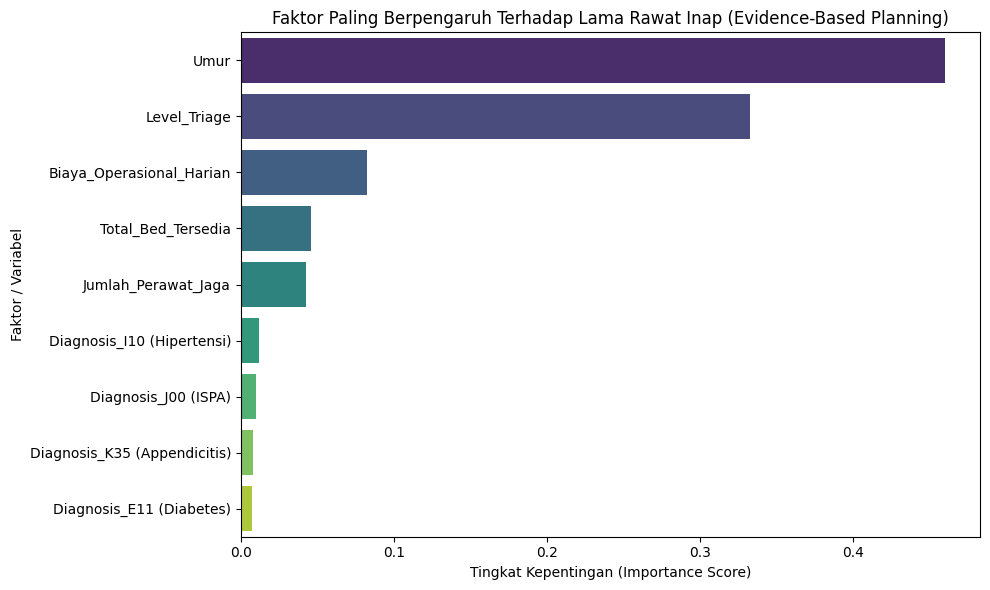


💡 INSIGHT MANAJERIAL:
Grafik di atas menunjukkan faktor apa yang harus dipantau manajemen.
Misal: Jika 'Level_Triage' paling tinggi, berarti alokasi bed harus fokus pada screening awal di IGD.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ==========================================
# 1. LOAD & PRE-PROCESSING (INTEROPERABILITAS)
# ==========================================

# Baca kembali file yang tadi dibuat
df_clin = pd.read_csv('data_klinis_pasien.csv')
df_ops = pd.read_csv('data_operasional_rs.csv')

# Pastikan format tanggal sama agar bisa digabungkan (Bridging)
df_clin['Tanggal_Masuk'] = pd.to_datetime(df_clin['Tanggal_Masuk'])
df_ops['Tanggal'] = pd.to_datetime(df_ops['Tanggal'])

# --- THE MAGIC MOMENT: INTEROPERABILITAS ---
# Menggabungkan data Medis dengan data Operasional berdasarkan tanggal
# Ini mensimulasikan sistem RS yang terintegrasi (Bridging System)
df_final = pd.merge(df_clin, df_ops, left_on='Tanggal_Masuk', right_on='Tanggal', how='left')

# Drop kolom tanggal (tidak dipakai untuk prediksi mesin) dan ID
df_model = df_final.drop(columns=['ID_Pasien', 'Tanggal_Masuk', 'Tanggal'])

# Ubah Data Kategori (Diagnosis) menjadi Angka (One-Hot Encoding)
df_model = pd.get_dummies(df_model, columns=['Diagnosis'], drop_first=True)

print("Data Terintegrasi (Siap untuk Machine Learning):")
print(df_model.head(3))
print("-" * 30)

# ==========================================
# 2. MACHINE LEARNING (PREDIKSI)
# ==========================================

# Tentukan Fitur (X) dan Target (y)
X = df_model.drop(columns=['Lama_Rawat_Hari']) # Data untuk memprediksi
y = df_model['Lama_Rawat_Hari']                # Apa yang mau diprediksi

# Bagi data: 80% untuk Latihan (Train), 20% untuk Ujian (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pilih Model: Random Forest Regressor
# Alasan: Bagus untuk data campuran angka & kategori, dan mudah dijelaskan
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Lakukan Prediksi pada data ujian
y_pred = model.predict(X_test)

# Evaluasi Akurasi
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n📊 HASIL EVALUASI MODEL:")
print(f"Rata-rata Kesalahan Prediksi (MAE): +/- {mae:.2f} Hari")
print(f"Penjelasan: Jika model memprediksi pasien pulang dalam 5 hari,")
print(f"kemungkinan aslinya antara {5-mae:.1f} sampai {5+mae:.1f} hari.")

# ==========================================
# 3. VISUALISASI (PERENCANAAN BERBASIS BUKTI)
# ==========================================

plt.figure(figsize=(10, 6))

# Tampilkan Fitur apa yang paling mempengaruhi Lama Rawat (Evidence Based)
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')
plt.title('Faktor Paling Berpengaruh Terhadap Lama Rawat Inap (Evidence-Based Planning)')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Faktor / Variabel')
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT MANAJERIAL:")
print("Grafik di atas menunjukkan faktor apa yang harus dipantau manajemen.")
print("Misal: Jika 'Level_Triage' paling tinggi, berarti alokasi bed harus fokus pada screening awal di IGD.")
